# 🧠 Visualisasi Granger Causality EEG - 2D Top-Down (Arah Atas)

Notebook ini digunakan untuk menghasilkan gambar visualisasi jaringan konektivitas otak (brain connectivity network) **2D dari arah atas (top-down view/axial projection)** secara rapi dan profesional.

### Fitur Utama:
1. **Proyeksi Arah Atas yang Rapi (Top-Down View):** Menggunakan bentuk kepala standar dengan penanda telinga dan hidung yang elegan, menyajikan visualisasi konektivitas axial secara komprehensif.
2. **Penyaringan Statistik Signifikan:** Hanya menampilkan koneksi dengan nilai signifikansi $p < 0.01$ dan membatasi jumlah garis terkuat (`n_lines=35`) agar gambar bersih dan tidak menumpuk.
3. **Desain Elegan untuk Publikasi:** Elektroda berkode warna lobus modern (Frontal: Merah, Central/Temporal: Cyan, Parietal: Kuning, Occipital: Ungu) dengan ukuran berbasis derajat node (degree).
4. **Konektivitas Berarah (Directed Arrows):** Koneksi digambarkan dengan panah melengkung (curved arrows) untuk menghindari tumpang tindih garis dua arah.

In [1]:
# ==============================================================================
# SECTION 1: IMPORT LIBRARIES
# ==============================================================================
import os
import warnings
import numpy as np
import mne
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable

# Abaikan warning matplotlib
warnings.filterwarnings('ignore')

## 📍 Pemetaan Koordinat Elektroda 2D (SEED 62 Channel)

Kita memetakan elektroda SEED ke posisi 2D berdasarkan template 3D standard 10-05 MNE-Python (dengan mengambil proyeksi sumbu horizontal $x$ dan $y$). Elektroda cerebellar **CB1** dan **CB2** dipetakan ke posisi standar **I1** dan **I2**.

In [2]:
# ==============================================================================
# SECTION 2: CHANNEL CONFIGURATION & 2D COORDINATES
# ==============================================================================

# Nama 62 elektroda EEG standar dari dataset SEED
channel_names = [
    'Fp1', 'Fpz', 'Fp2', 'AF3', 'AF4', 'F7', 'F5', 'F3', 'F1', 'Fz', 'F2', 'F4', 'F6', 'F8',
    'FT7', 'FC5', 'FC3', 'FC1', 'FCz', 'FC2', 'FC4', 'FC6', 'FT8', 'T7', 'C5', 'C3', 'C1',
    'Cz', 'C2', 'C4', 'C6', 'T8', 'TP7', 'CP5', 'CP3', 'CP1', 'CPz', 'CP2', 'CP4', 'CP6',
    'TP8', 'P7', 'P5', 'P3', 'P1', 'Pz', 'P2', 'P4', 'P6', 'P8', 'PO7', 'PO5', 'PO3',
    'POz', 'PO4', 'PO6', 'PO8', 'CB1', 'O1', 'Oz', 'O2', 'CB2'
]

# Pembagian lobus otak untuk pewarnaan node
frontal_lobes = ['FP1', 'FPZ', 'FP2', 'AF3', 'AF4', 'F7', 'F5', 'F3', 'F1', 'FZ', 'F2', 'F4', 'F6', 'F8']
central_lobes = ['FT7', 'FC5', 'FC3', 'FC1', 'FCZ', 'FC2', 'FC4', 'FC6', 'FT8', 'T7', 'C5', 'C3', 'C1', 'CZ', 'C2', 'C4', 'C6', 'T8']
parietal_lobes = ['TP7', 'CP5', 'CP3', 'CP1', 'CPZ', 'CP2', 'CP4', 'CP6', 'TP8', 'P7', 'P5', 'P3', 'P1', 'PZ', 'P2', 'P4', 'P6', 'P8']
occipital_lobes = ['PO7', 'PO5', 'PO3', 'POZ', 'PO4', 'PO6', 'PO8', 'CB1', 'O1', 'OZ', 'O2', 'CB2']

node_colors = []
for name in channel_names:
    ch_upper = name.upper()
    if ch_upper in frontal_lobes:
        node_colors.append('#E84A5F')  # Coral Red (Frontal)
    elif ch_upper in central_lobes:
        node_colors.append('#3EC1D3')  # Cyan (Central/Temporal)
    elif ch_upper in parietal_lobes:
        node_colors.append('#F9A826')  # Golden Yellow (Parietal)
    elif ch_upper in occipital_lobes:
        node_colors.append('#4A47A3')  # Indigo Purple (Occipital)
    else:
        node_colors.append('#95A5A6')

# Ambil posisi elektroda dari database MNE
montage_1005 = mne.channels.make_standard_montage('standard_1005')
positions_db = montage_1005.get_positions()['ch_pos']

# Ekstrak koordinat 2D (x, y)
node_coords_2d = {}
for name in channel_names:
    ch_upper = name.upper()
    if ch_upper == 'CB1':
        pos = positions_db['I1']
    elif ch_upper == 'CB2':
        pos = positions_db['I2']
    else:
        pos = None
        for k in positions_db.keys():
            if k.upper() == ch_upper:
                pos = positions_db[k]
                break
        if pos is None:
            pos = np.array([0.0, 0.0, 0.0])
            
    # Gunakan koordinat x dan y standar (diskala untuk keselarasan plot)
    node_coords_2d[name] = (pos[0] * 12, pos[1] * 12)

print("✓ Berhasil memetakan koordinat 2D elektroda.")

✓ Berhasil memetakan koordinat 2D elektroda.


## 📐 Fungsi Utama Visualisasi Konektivitas 2D Top-Down

Fungsi `plot_eeg_connectome_2d` menggambar outline kepala standar yang tipis dan elegan, menyaring koneksi non-signifikan, lalu memplot panah konektivitas melengkung berdasarkan kekuatan nilai Granger Causality.

In [3]:
# ==============================================================================
# SECTION 3: EEG 2D TOP-DOWN CONNECTOME PLOTTING FUNCTION
# ==============================================================================

def plot_eeg_connectome_2d(gc_matrix, p_matrix, ax, title, n_lines=35):
    """
    Memplot konektivitas EEG 2D dari atas pada axis Matplotlib yang diberikan.
    """
    head_radius = 1.0
    
    # 1. Gambar outline kepala
    head_circle = plt.Circle((0, 0), head_radius, fill=False, color='#7F8C8D', linewidth=2.0)
    ax.add_patch(head_circle)
    
    # Hidung (nose)
    nose_x = [-0.10, 0, 0.10]
    nose_y = [head_radius, head_radius + 0.12, head_radius]
    ax.plot(nose_x, nose_y, color='#7F8C8D', linewidth=2.0)
    
    # Telinga (ears)
    left_ear = mpatches.Ellipse((-head_radius - 0.05, 0), 0.06, 0.20, fill=False, color='#7F8C8D', linewidth=1.5)
    ax.add_patch(left_ear)
    right_ear = mpatches.Ellipse((head_radius + 0.05, 0), 0.06, 0.20, fill=False, color='#7F8C8D', linewidth=1.5)
    ax.add_patch(right_ear)
    
    # 2. Filter data konektivitas
    gc_work = gc_matrix.copy()
    np.fill_diagonal(gc_work, 0)
    
    significant = (p_matrix < 0.01)
    gc_filtered = gc_work * significant
    
    if np.any(gc_filtered > 0):
        total_valid = np.count_nonzero(gc_filtered)
        if total_valid > n_lines:
            threshold_val = np.percentile(gc_filtered[gc_filtered > 0], 100 - (100 * n_lines / total_valid))
        else:
            threshold_val = gc_filtered[gc_filtered > 0].min()
    else:
        threshold_val = 0.5
        
    adj_matrix = np.where(gc_filtered >= threshold_val, gc_filtered, 0)
    
    # Derajat node untuk penskalaan
    degrees = np.sum(adj_matrix > 0, axis=0) + np.sum(adj_matrix > 0, axis=1)
    deg_min, deg_max = degrees.min(), degrees.max()
    node_sizes = 50 + 130 * (degrees - deg_min) / (deg_max - deg_min + 1e-5)
    
    # Kumpulkan koneksi terkuat
    connections = []
    n_nodes = len(channel_names)
    for i in range(n_nodes):
        for j in range(n_nodes):
            if adj_matrix[i, j] > 0:
                connections.append({
                    'from': channel_names[i],
                    'to': channel_names[j],
                    'strength': adj_matrix[i, j]
                })
    connections.sort(key=lambda x: x['strength'])
    
    if not connections:
        ax.set_title(title, fontsize=16, fontweight='bold', pad=15)
        return ax
        
    # Konfigurasi cmap untuk edge
    cmap = plt.colormaps.get_cmap('YlOrRd')
    strengths = [c['strength'] for c in connections]
    norm = Normalize(vmin=min(strengths), vmax=max(strengths))
    
    # 3. Plot panah koneksi (melengkung agar tidak tumpang tindih)
    for conn in connections:
        from_ch, to_ch = conn['from'], conn['to']
        strength = conn['strength']
        
        x1, y1 = node_coords_2d[from_ch]
        x2, y2 = node_coords_2d[to_ch]
        
        color = cmap(norm(strength))
        linewidth = 1.0 + 3.5 * norm(strength)
        alpha = 0.70 + 0.30 * norm(strength)
        
        dx, dy = x2 - x1, y2 - y1
        dist = np.sqrt(dx**2 + dy**2)
        if dist > 0:
            # Persingkat garis agar panah tidak menusuk ke dalam bulatan elektroda
            shrink = 0.08
            x1_new = x1 + shrink * dx / dist
            y1_new = y1 + shrink * dy / dist
            x2_new = x2 - shrink * dx / dist
            y2_new = y2 - shrink * dy / dist
            
            ax.annotate('', 
                        xy=(x2_new, y2_new), 
                        xytext=(x1_new, y1_new),
                        arrowprops=dict( 
                            arrowstyle='-|>',
                            color=color,
                            alpha=alpha,
                            lw=linewidth,
                            mutation_scale=12,  # Ukuran kepala panah
                            connectionstyle='arc3,rad=0.15'  # Sudut lengkungan panah
                        ))
            
    # 4. Plot bulatan elektroda & label teks bersih
    for idx, name in enumerate(channel_names):
        x, y = node_coords_2d[name]
        color = node_colors[idx]
        size = node_sizes[idx]
        
        # Bulatan elektroda
        ax.scatter(x, y, s=size, color=color, zorder=10, edgecolors='white', linewidths=1.2, alpha=0.95)
        # Label teks elektroda (Tanpa ada karakter '?')
        ax.text(x, y + 0.04, name, ha='center', va='bottom', fontsize=8, fontweight='bold', color='#2C3E50', zorder=12)
        
    ax.set_xlim(-head_radius - 0.2, head_radius + 0.2)
    ax.set_ylim(-head_radius - 0.2, head_radius + 0.2)
    ax.set_aspect('equal')
    ax.axis('off')
    ax.set_title(title, fontsize=16, fontweight='bold', color='#1A252C', pad=15)

## 🚀 Eksekusi dan Pembuatan Gambar Perbandingan (3 Emosi)

Kita memuat matriks Granger Causality untuk Subject 1 (Session `20131027`) pada 3 emosi (Negative, Neutral, Positive) lalu menggambar plot perbandingan berdampingan (*side-by-side*) yang bersih dan rapi.

Processing: NEGATIVE...
Processing: NEUTRAL...


Processing: POSITIVE...



✓ Gambar perbandingan berhasil disimpan di: d:\Skripsi\new_data\01_granger_causality\figures\gc_2d_topdown_comparison.png


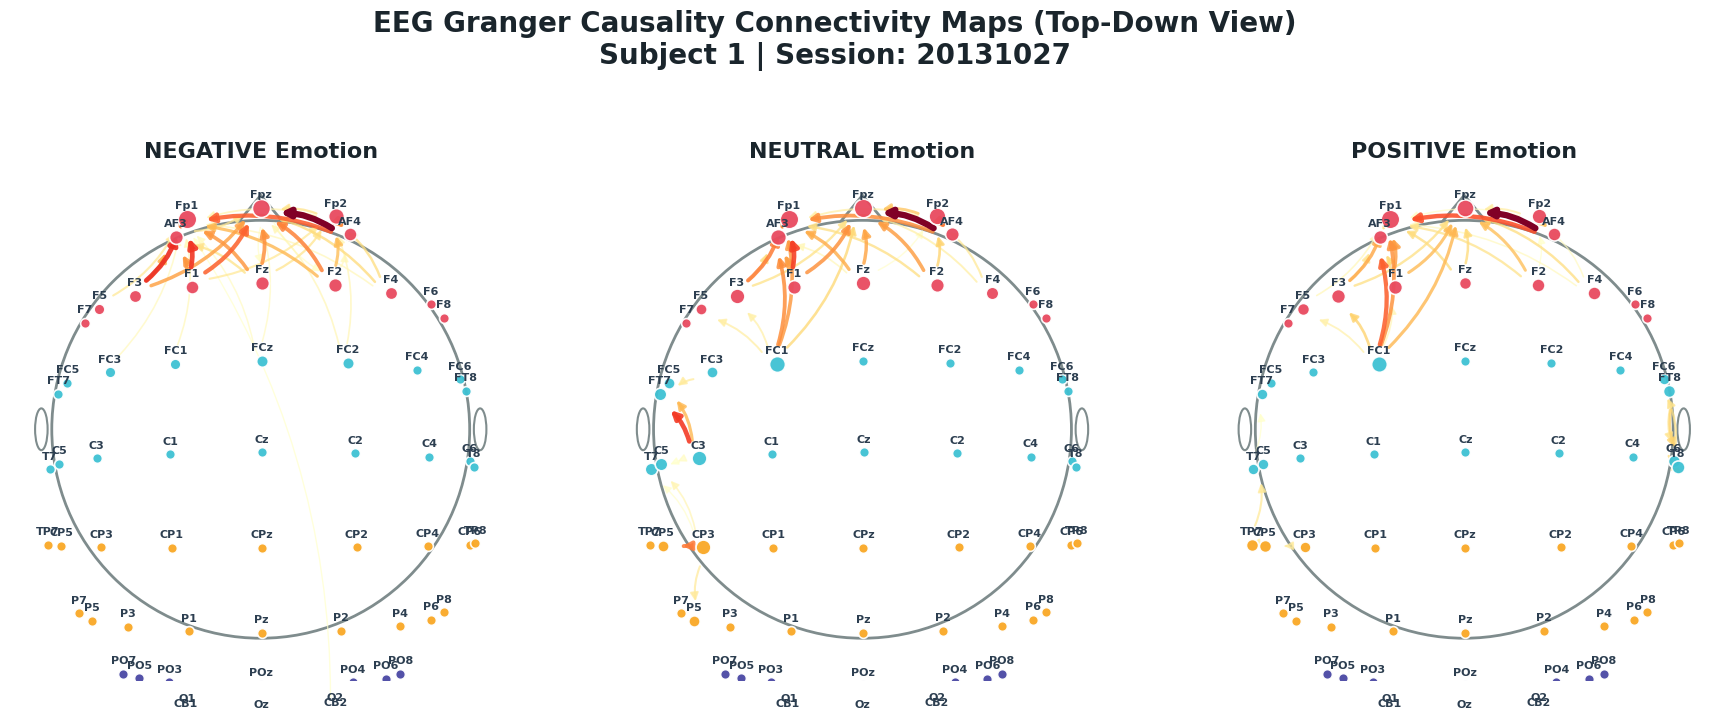

In [4]:
# ==============================================================================
# SECTION 4: DATA LOAD & EXECUTION (2D SIDE-BY-SIDE COMPILATION)
# ==============================================================================

subject_id = "subject_1"
session_date = "20131027"

base_dir = r"d:\Skripsi"
granger_dir = os.path.join(base_dir, "HasilGrangerPDC", "GrangerCausality")
session_dir = os.path.join(granger_dir, subject_id, session_date)
output_dir = os.path.join(base_dir, "new_data", "01_granger_causality", "figures")
os.makedirs(output_dir, exist_ok=True)

emotions = ["negative", "neutral", "positive"]

# Buat figure perbandingan berdampingan (1 baris, 3 kolom)
fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(22, 8), facecolor='white')

for idx, emotion in enumerate(emotions):
    print(f"Processing: {emotion.upper()}...")
    gc_file = os.path.join(session_dir, f"gc_matrix_{emotion}.npy")
    p_file = os.path.join(session_dir, f"p_matrix_{emotion}.npy")
    
    if not os.path.exists(gc_file) or not os.path.exists(p_file):
        print(f"⚠️ Berkas {emotion} tidak ada. Lewat.")
        continue
        
    gc_matrix = np.load(gc_file)
    p_matrix = np.load(p_file)
    
    # Plot masing-masing emosi pada subplotnya
    plot_eeg_connectome_2d(gc_matrix, p_matrix, axes[idx], f"{emotion.upper()} Emotion", n_lines=35)

# Berikan Judul Utama dan Info Tambahan
plt.suptitle(f"EEG Granger Causality Connectivity Maps (Top-Down View)\n{subject_id.replace('_', ' ').title()} | Session: {session_date}", 
             fontsize=20, fontweight='bold', color='#1A252C', y=1.02)

# Simpan gambar perbandingan
save_path_comp = os.path.join(output_dir, "gc_2d_topdown_comparison.png")
plt.savefig(save_path_comp, dpi=300, bbox_inches='tight')
print(f"\n✓ Gambar perbandingan berhasil disimpan di: {save_path_comp}")

# Tampilkan plot
plt.show()
plt.close()

## 🎨 Pembuatan Gambar Individual Beresolusi Tinggi

Untuk keperluan penulisan skripsi yang fleksibel, kita juga menyimpan masing-masing gambar kondisi emosi sebagai berkas gambar individual beresolusi tinggi (300 DPI).

✓ Gambar individual NEGATIVE berhasil disimpan di: d:\Skripsi\new_data\01_granger_causality\figures\gc_2d_topdown_negative.png


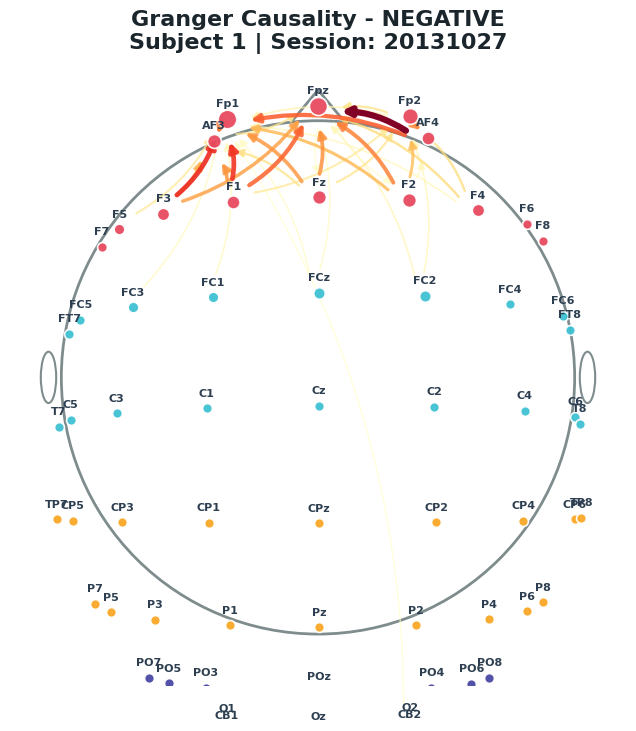

✓ Gambar individual NEUTRAL berhasil disimpan di: d:\Skripsi\new_data\01_granger_causality\figures\gc_2d_topdown_neutral.png


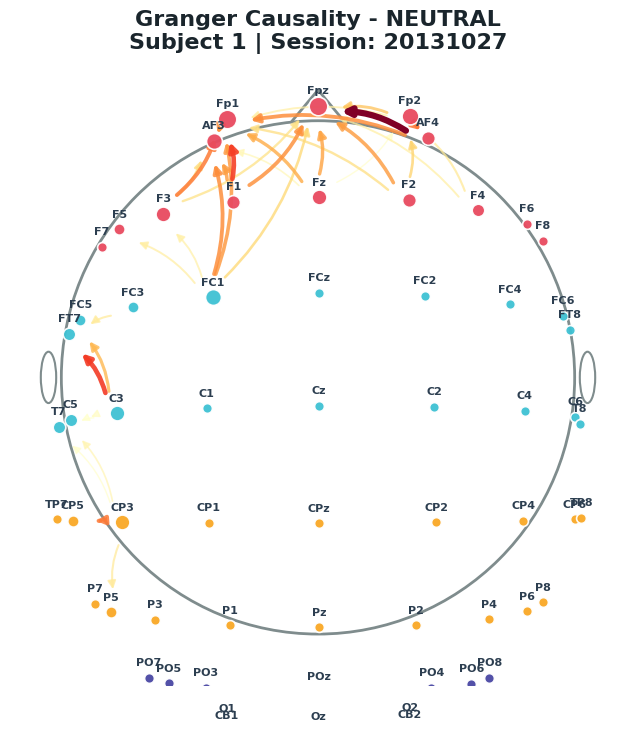

✓ Gambar individual POSITIVE berhasil disimpan di: d:\Skripsi\new_data\01_granger_causality\figures\gc_2d_topdown_positive.png


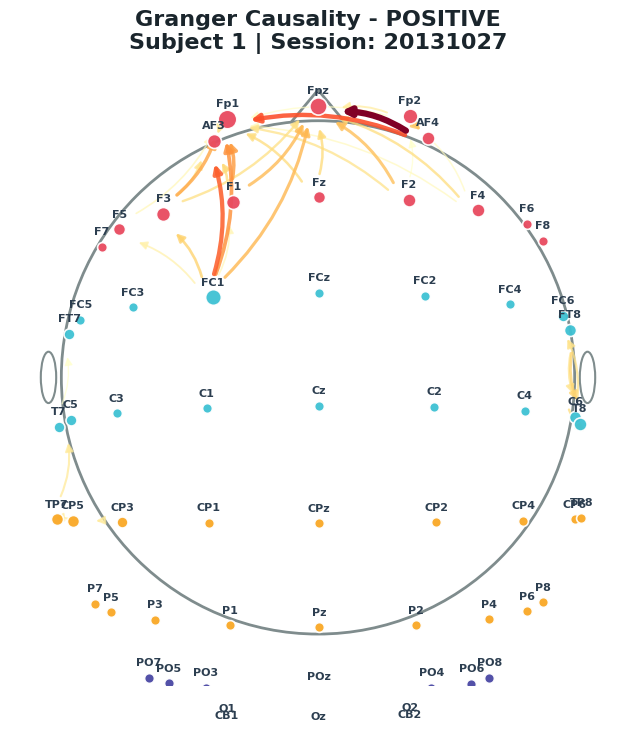


🎉 SEMURAH-MURAHNYA DOKUMEN 2D SELESAI DENGAN RAPI!


In [5]:
# ==============================================================================
# SECTION 5: GENERATE INDIVIDUAL HIGH-RES 2D FIGURES
# ==============================================================================

for emotion in emotions:
    gc_file = os.path.join(session_dir, f"gc_matrix_{emotion}.npy")
    p_file = os.path.join(session_dir, f"p_matrix_{emotion}.npy")
    
    if not os.path.exists(gc_file) or not os.path.exists(p_file):
        continue
        
    gc_matrix = np.load(gc_file)
    p_matrix = np.load(p_file)
    
    # Buat figure khusus untuk 1 emosi
    fig, ax = plt.subplots(figsize=(8, 8), facecolor='white')
    
    title_single = f"Granger Causality - {emotion.upper()}\n{subject_id.replace('_', ' ').title()} | Session: {session_date}"
    plot_eeg_connectome_2d(gc_matrix, p_matrix, ax, title_single, n_lines=35)
    
    # Simpan berkas individual
    save_path_single = os.path.join(output_dir, f"gc_2d_topdown_{emotion}.png")
    plt.savefig(save_path_single, dpi=300, bbox_inches='tight')
    print(f"✓ Gambar individual {emotion.upper()} berhasil disimpan di: {save_path_single}")
    
    plt.show()
    plt.close()

print("\n🎉 SEMURAH-MURAHNYA DOKUMEN 2D SELESAI DENGAN RAPI!")